# 01 — Data pipeline

Sources ranked by quality: **SEC EDGAR** (official, legal documents) > **Polymarket Gamma** (real money) > **FRED** (official macro) > **yfinance** (market data, Stooq fallback) > **HN/Wikipedia** (attention proxies). Every fetch passes a quality gate. Universe: portfolio (GOOGL), volatility proxy (TSLA), picks-and-shovels (NDAQ, HOOD, VIRT, GS, MS), space sector (RKLB, ASTS, LMT), benchmarks (^GSPC, ^NDX) and the fear gauge (^VIX).

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, headline, PALETTE, GOOD, BAD, NEUTRAL
tufte_style()

## 1. OHLCV with quality gate

Data-engineering rule: nothing enters the process without passing the checks. **Issues** (NaN, non-positive prices, staleness) block the pipeline; **warnings** (gaps, >50% jumps) are surfaced for human review — extreme moves can be real (ASTS +50% on the AT&T deal, ^VIX Fed-day spikes), so they must be flagged, not auto-dropped.

In [2]:
from src.connectors.market_data import get_universe
from src.config import UNIVERSE  # noqa: F401
prices, reports = get_universe(UNIVERSE, period="2y")
qa = pd.DataFrame(reports).set_index("ticker")
assert qa["issues"].map(len).sum() == 0, f"QUALITY FAIL: {qa[qa.issues.map(len)>0]}"
prices.to_parquet("../data/universe_prices.parquet")
qa

,rows,first,last,missing_bdays,issues,warnings
ticker,,,,,,
GOOGL,500,2024-06-11,2026-06-09,21,[],[]
TSLA,500,2024-06-11,2026-06-09,21,[],[]
NDAQ,500,2024-06-11,2026-06-09,21,[],[]
HOOD,500,2024-06-11,2026-06-09,21,[],[]
VIRT,500,2024-06-11,2026-06-09,21,[],[]
GS,500,2024-06-11,2026-06-09,21,[],[]
MS,500,2024-06-11,2026-06-09,21,[],[]
RKLB,501,2024-06-11,2026-06-10,21,[],[]
ASTS,501,2024-06-11,2026-06-10,21,[],[jump >50% on 2024-08-15 (verify: real move or...


## 2. SEC EDGAR — SpaceX filings (CIK 1181412)

The single most authoritative source: filings are legal acts. From August this is where **Form 4s** appear (insider sales, public by law within 2 business days) — the key dataset for the lockup thesis.

In [3]:
from src.connectors.edgar import recent_filings, form4_watch
fil = pd.DataFrame(recent_filings(limit=15))
print(f"Form 3/4/144 to date: {len(form4_watch())} (expected from August)")
fil

Form 3/4/144 to date: 0 (expected from August)


,form,date,url
0,CERT,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
1,8-A12B,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
2,8-A12B,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
3,CERT,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
4,FWP,2026-06-09,https://www.sec.gov/Archives/edgar/data/118141...
5,FWP,2026-06-08,https://www.sec.gov/Archives/edgar/data/118141...
6,FWP,2026-06-05,https://www.sec.gov/Archives/edgar/data/118141...
7,FWP,2026-06-05,https://www.sec.gov/Archives/edgar/data/118141...
8,FWP,2026-06-04,https://www.sec.gov/Archives/edgar/data/118141...
9,FWP,2026-06-04,https://www.sec.gov/Archives/edgar/data/118141...


## 3. Polymarket — real-money implied probabilities

In [4]:
from src.connectors.polymarket import search_markets
mkts = search_markets("spacex", limit=10)
pm = pd.DataFrame([{ "market": m["market"], **{f"P({k})": v for k, v in m["outcomes"].items()}, "volume_usd": int(m["volume"])} for m in mkts])
pm

,market,P(Yes),P(No),volume_usd
0,SpaceX IPO closing market cap above $3T?,0.0650,0.9350,1871019
1,SpaceX IPO closing market cap above $2T?,0.6250,0.3750,1126717
2,SpaceX IPO closing market cap above $1.8T?,0.8250,0.1750,1031437
3,Will SpaceX's market cap be between $2.5T and ...,0.1630,0.8370,912938
4,"Will SpaceX IPO by May 31, 2026?",0.0000,1.0000,906312
5,SpaceX IPO closing market cap above $2.4T?,0.2350,0.7650,889423
6,SpaceX IPO closing market cap above $1T?,0.9930,0.0070,754203
7,Will SpaceX's market cap be greater than $1T a...,0.9920,0.0080,751047
8,"Will SpaceX IPO by June 30, 2026?",0.9975,0.0025,685045
9,SpaceX IPO closing market cap above $2.6T?,0.1400,0.8600,677850


## 4. Risk-free rate (FRED, ^IRX fallback)

In [5]:
from src.connectors.fred import risk_free_rate
RF = risk_free_rate()
print(f"3M T-bill: {RF:.2%} — the hurdle every strategy must beat, plus friction")

3M T-bill: 3.63% — the hurdle every strategy must beat, plus friction


## 5. Normalized prices — one chart, all the information

Base 100, direct labels (no legend to decode), benchmarks in gray. ^VIX excluded here (different unit), used in notebook 02.

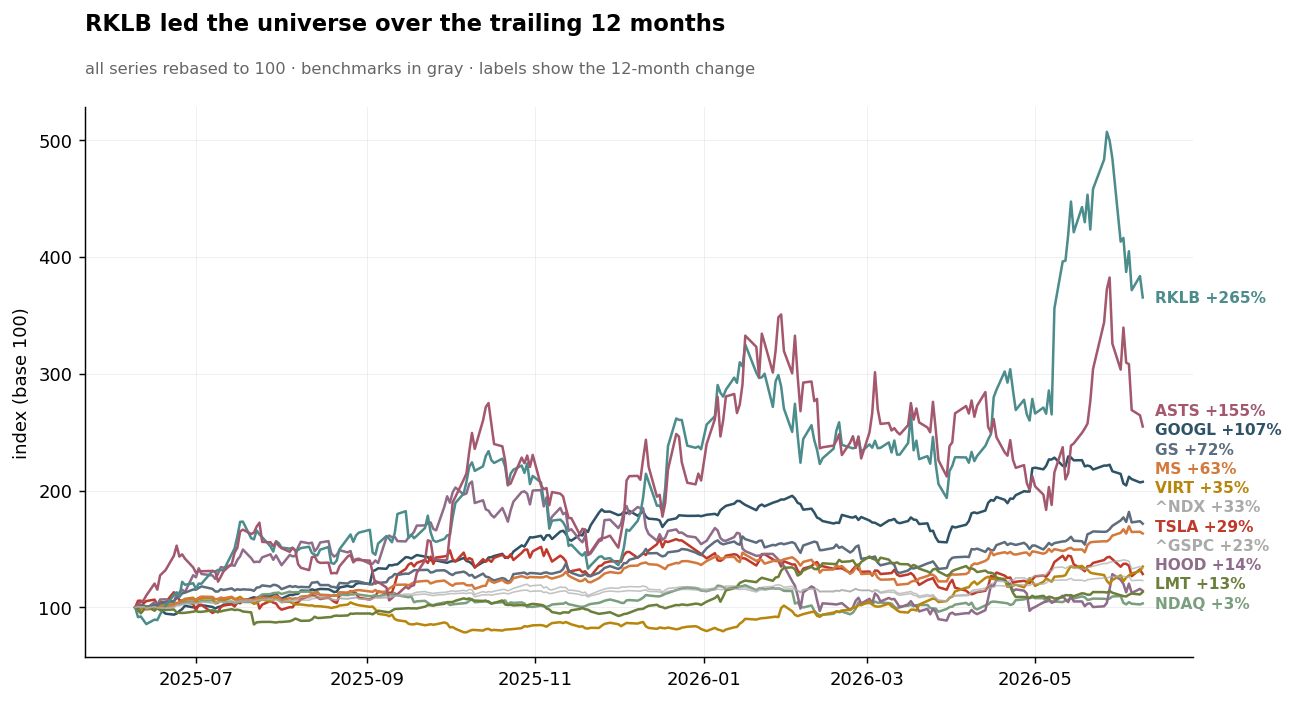

In [6]:
px = prices.drop(columns=["^VIX"]).dropna().tail(252)
norm = 100 * px / px.iloc[0]
fig, ax = plt.subplots(figsize=(11, 5.5))
for c in norm.columns:
    is_bench = c.startswith("^")
    ax.plot(norm.index, norm[c], lw=0.9 if is_bench else 1.4,
            color="#AAAAAA" if is_bench else None, alpha=0.7 if is_bench else 1)
fmt = {c: f"{c} {norm[c].dropna().iloc[-1]-100:+.0f}%" for c in norm.columns}
direct_label_lines(ax, norm, fmt=fmt)
leader = max(norm.columns, key=lambda c: norm[c].dropna().iloc[-1])
headline(ax, f"{leader} led the universe over the trailing 12 months",
         "all series rebased to 100 · benchmarks in gray · labels show the 12-month change")
ax.set_ylabel("index (base 100)")
fig.savefig("../assets/chart_universe.png", bbox_inches="tight")
plt.show()